<h1 style="text-align:center;">Pandas</h1>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Pandas Series

A Pandas Series is like a column in a table. It is a 1-D array holding data of any type.


### Series from List


In [65]:
# strings

country = ["India", "Pakistan", "USA", "Nepal", "Sri Lanka"]

pd.Series(country)
# in most cases, python inteprets strings as objects

0        India
1     Pakistan
2          USA
3        Nepal
4    Sri Lanka
dtype: object

In [66]:
# integers

runs = [13, 24, 56, 78, 100]
runs_ser = pd.Series(runs)
runs_ser

0     13
1     24
2     56
3     78
4    100
dtype: int64

In [ ]:
# custom index

marks = [67, 57, 99, 45, 100]

subjects = ["Hindi", "English", "Maths", "Sanskrit", "Science"]

pd.Series(marks, index=subjects)

Hindi        67
English      57
Maths        99
Sanskrit     45
Science     100
dtype: int64

In [ ]:
# setting a name

marks = pd.Series(marks, name="Aryan marks")
marks

0     67
1     57
2     99
3     45
4    100
Name: Aryan marks, dtype: int64

### Series from dict


In [69]:
marks_dict = dict(zip(subjects, marks))

marks_series = pd.Series(marks_dict, name="Aryan ke marks")
marks_series

Hindi        67
English      57
Maths        99
Sanskrit     45
Science     100
Name: Aryan ke marks, dtype: int64

### Series Attributes


In [70]:
# size

# represents total values in the series

marks_series.size

5

In [71]:
# dtype
# Heterogenous data (like strings and int) will be treated object (string)

marks_series.dtype

dtype('int64')

In [ ]:
# name

marks_series.name

'Aryan ke marks'

In [73]:
# is_unique

# returns False if items are repeating

marks_series.is_unique

True

In [ ]:
# index

# returns all the index(s)

marks_series.index  # returns an index object

Index(['Hindi', 'English', 'Maths', 'Sanskrit', 'Science'], dtype='object')

In [75]:
runs_ser.index  # returns a RangeIndex object

RangeIndex(start=0, stop=5, step=1)

In [76]:
# values

marks_series.values     # returns ndarray

array([ 67,  57,  99,  45, 100])

### Series using read_csv


In [ ]:
# with one col

# name will be the column header of values

print(type(pd.read_csv("data/subs.csv")))    # actually a dataframe
# squeezes into series along default axis/column
subs = pd.read_csv('data/subs.csv').squeeze()
subs

<class 'pandas.core.frame.DataFrame'>


0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [78]:
# makes match_no column as index
kohli_runs = pd.read_csv('data/kohli_ipl.csv', index_col='match_no').squeeze()
kohli_runs

match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64

In [79]:
b_movies = pd.read_csv('data/bollywood.csv', index_col='movie').squeeze()
b_movies

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object

### Series Methods


In [ ]:
# head and tail => used to preview data

# head(n=5) => shows top n values
# tail(n=5) => shows bottom n values

kohli_runs.head(3)

match_no
1     1
2    23
3    13
Name: runs, dtype: int64

In [81]:
b_movies.tail(6)

movie
Kaante                    Amitabh Bachchan
Hum Tumhare Hain Sanam      Shah Rukh Khan
Aankhen (2002 film)       Amitabh Bachchan
Saathiya (film)               Vivek Oberoi
Company (film)                  Ajay Devgn
Awara Paagal Deewana          Akshay Kumar
Name: lead, dtype: object

In [ ]:
# sample(n=1)

# shows n row randomly from the data
# used when the data is biased on some parameter, so you can view random values

b_movies.sample(5)

movie
Gayab                      Tusshar Kapoor
Fareb (2005 film)    Shilpa Shetty Kundra
Om Shanti Om               Shah Rukh Khan
Guzaarish (film)           Hrithik Roshan
Lafangey Parindey       Neil Nitin Mukesh
Name: lead, dtype: object

In [ ]:
# value_counts()  -> gives frequency count

# gives the frequency of values (lead in this case) in desc order
b_movies.value_counts()

lead
Akshay Kumar            48
Amitabh Bachchan        45
Ajay Devgn              38
Salman Khan             31
Sanjay Dutt             26
                        ..
Tanishaa Mukerji         1
Tanuja                   1
Ankit                    1
Rakhee Gulzar            1
Geetika Vidya Ohlyan     1
Name: count, Length: 566, dtype: int64

In [ ]:
# sort_values()

# use ascending=False for desc

kohli_runs.sort_values(ascending=False)    # default is asc

# to do inplace sorting (affect on original series) use inplace=True

match_no
128    113
126    109
123    108
120    100
164    100
      ... 
93       0
130      0
206      0
207      0
211      0
Name: runs, Length: 215, dtype: int64

In [85]:
# sort_index() --> sorts the index(s)

# also has inplace parameter

b_movies.sort_index()

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)              Arjun Kapoor
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: object

### Mathematical Functions


In [ ]:
# count

# doesn't count missing values, however size does

kohli_runs.count()

np.int64(215)

In [87]:
# sum and product

print(subs.sum())
subs.product()

49510


np.int64(0)

In [ ]:
# mean, median, mode, var, std

print(kohli_runs.median())
print(b_movies.mode())  # returns a series object
print(subs.std())
print(kohli_runs.var())
subs.mean()

24.0
0    Akshay Kumar
Name: lead, dtype: object
62.6750230372527
688.0024777222343


np.float64(135.64383561643837)

In [ ]:
# min/max

print(subs.max())
subs.min()

396


np.int64(33)

In [90]:
# describe

# provides a summary

kohli_runs.describe()

count    215.000000
mean      30.855814
std       26.229801
min        0.000000
25%        9.000000
50%       24.000000
75%       48.000000
max      113.000000
Name: runs, dtype: float64

### Indexing

during the case of indexing in series by default pandas uses the
label based indexing and for any position based indexing we need to use.iloc[]
but for the slicing default one is position based so if we want to do label based there we need to use .loc[]


In [91]:
# Negative indexing doesn't work here

x = pd.Series(np.random.random(10)*50)
x

0    13.211041
1     1.071212
2    45.145365
3     6.843182
4     8.124770
5     8.919433
6     5.488065
7     7.521775
8    31.761790
9    35.475052
dtype: float64

In [ ]:
x[-1]

# Raises KeyError

In [ ]:
# the default position based indexing is also available even if label indexing is provided
# but it is deprecated. So use, .iloc[] for position based indexing
# and .loc[] for label based indexing

b_movies.iloc[0]

'Vicky Kaushal'

In [ ]:
b_movies.loc['Uri: The Surgical Strike']

'Vicky Kaushal'

In [ ]:
b_movies.iloc[-1]       # negative indexing works with iloc[]

'Akshay Kumar'

In [ ]:
# slicing and fancy indexing works in the same manner

# with both .iloc[] for position based indexing
# and .loc[] for label based indexing

# Series are mutable and can be changed by indexing assignment
# a new element can be added by indexing it

### Series with python functionalities


In [ ]:
# len/type/dir/sorted/max/min

print(len(subs))
print(type(subs))
print(sorted(subs))
print(min(subs))
print(max(subs))
print(dir(subs))

365
<class 'pandas.core.series.Series'>
[33, 33, 35, 37, 39, 40, 40, 40, 40, 42, 42, 43, 44, 44, 44, 45, 46, 46, 48, 49, 49, 49, 49, 50, 50, 50, 51, 54, 56, 56, 56, 56, 57, 61, 62, 64, 65, 65, 66, 66, 66, 66, 67, 68, 70, 70, 70, 71, 71, 72, 72, 72, 72, 72, 73, 74, 74, 75, 76, 76, 76, 76, 77, 77, 78, 78, 78, 79, 79, 80, 80, 80, 81, 81, 82, 82, 83, 83, 83, 84, 84, 84, 85, 86, 86, 86, 87, 87, 87, 87, 88, 88, 88, 88, 88, 89, 89, 89, 90, 90, 90, 90, 91, 92, 92, 92, 93, 93, 93, 93, 95, 95, 96, 96, 96, 96, 97, 97, 98, 98, 99, 99, 100, 100, 100, 101, 101, 101, 102, 102, 103, 103, 104, 104, 104, 105, 105, 105, 105, 105, 105, 105, 105, 105, 108, 108, 108, 108, 108, 108, 109, 109, 110, 110, 110, 111, 111, 112, 113, 113, 113, 114, 114, 114, 114, 115, 115, 115, 115, 117, 117, 117, 118, 118, 119, 119, 119, 119, 120, 122, 123, 123, 123, 123, 123, 124, 125, 126, 127, 128, 128, 129, 130, 131, 131, 132, 132, 134, 134, 134, 135, 135, 136, 136, 136, 137, 138, 138, 138, 139, 140, 144, 145, 146, 146, 146, 1

In [ ]:
# type conversion
list(marks_series)

[67, 57, 99, 45, 100]

In [ ]:
dict(marks_series)

{'Hindi': np.int64(67),
 'English': np.int64(57),
 'Maths': np.int64(99),
 'Sanskrit': np.int64(45),
 'Science': np.int64(100)}

In [ ]:
# membership operator

'2 States (2014 film)' in b_movies
# default behaviour is search in index

True

In [ ]:
'Alia Bhatt' in b_movies.values

True

In [ ]:
# looping == default behaviour is loop over values
for i in b_movies.index:
    print(i)

Uri: The Surgical Strike
Battalion 609
The Accidental Prime Minister (film)
Why Cheat India
Evening Shadows
Soni (film)
Fraud Saiyaan
Bombairiya
Manikarnika: The Queen of Jhansi
Thackeray (film)
Amavas
Gully Boy
Hum Chaar
Total Dhamaal
Sonchiriya
Badla (2019 film)
Mard Ko Dard Nahi Hota
Hamid (film)
Photograph (film)
Risknamaa
Mere Pyare Prime Minister
22 Yards
Kesari (film)
Notebook (2019 film)
Junglee (2019 film)
Gone Kesh
Albert Pinto Ko Gussa Kyun Aata Hai?
The Tashkent Files
Kalank
Setters (film)
Student of the Year 2
PM Narendra Modi
De De Pyaar De
India's Most Wanted (film)
Yeh Hai India
Khamoshi (2019 film)
Kabir Singh
Article 15 (film)
One Day: Justice Delivered
Hume Tumse Pyaar Kitna
Super 30 (film)
Family of Thakurganj
Batla House
Jhootha Kahin Ka
Judgementall Hai Kya
Chicken Curry Law
Arjun Patiala
Jabariya Jodi
Pranaam
The Sky Is Pink
Mission Mangal
Saaho
Dream Girl (2019 film)
Section 375
The Zoya Factor (film)
Pal Pal Dil Ke Paas
Prassthanam
P Se Pyaar F Se Faraar
Ghost 

In [ ]:
# Arithmetic Operators(Broadcasting)
100 + marks_series

Hindi       167
English     157
Maths       199
Sanskrit    145
Science     200
Name: Aryan ke marks, dtype: int64

In [ ]:
# Relational Operators

print(kohli_runs > 50)      # returns boolean series
kohli_runs[kohli_runs > 50]     # returns a series

match_no
1      False
2      False
3      False
4      False
5      False
       ...  
211    False
212    False
213     True
214    False
215    False
Name: runs, Length: 215, dtype: bool


match_no
34      58
41      71
44      56
45      67
52      70
57      57
68      73
71      51
73      58
74      65
80      57
81      93
82      99
85      56
97      67
99      73
103     51
104     62
110     82
116     75
117     79
119     80
120    100
122     52
123    108
126    109
127     75
128    113
129     54
131     54
132     62
134     64
137     55
141     58
144     57
145     92
148     68
152     70
160     84
162     67
164    100
175     72
178     90
188     72
197     51
198     53
209     58
213     73
Name: runs, dtype: int64

### Plotting graphs on series


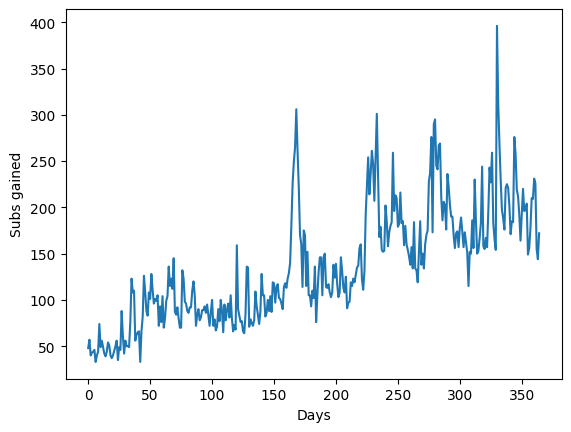

In [ ]:
subs.plot()     # ### pandas.plot() not plt.plot()
plt.xlabel("Days")
plt.ylabel("Subs gained")
plt.show()

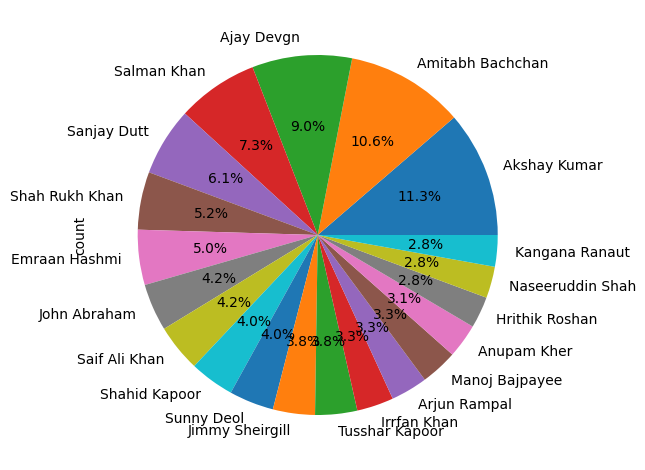

In [ ]:
b_movies.value_counts().head(20).plot(kind='pie', autopct='%1.1f%%')
plt.tight_layout()
plt.show()

### Some important Series methods


In [ ]:
# astype
# between
# clip
# drop_duplicates
# isnull
# dropna
# fillna
# isin
# apply
# copy

In [ ]:
# astype

import sys

print(sys.getsizeof(kohli_runs))    # int64
print(sys.getsizeof(kohli_runs.astype('int16')))

3472
2182


In [ ]:
# between

kohli_runs.iloc[0] = 51
kohli_runs.iloc[1] = 99
print(kohli_runs.between(51, 99))  # gives boolean series, both value inclusive

kohli_runs.loc[kohli_runs.between(51, 99)]
# use loc to use boolean array/series

match_no
1       True
2       True
3      False
4      False
5      False
       ...  
211    False
212    False
213     True
214    False
215    False
Name: runs, Length: 215, dtype: bool


match_no
1      51
2      99
34     58
41     71
44     56
45     67
52     70
57     57
68     73
71     51
73     58
74     65
80     57
81     93
82     99
85     56
97     67
99     73
103    51
104    62
110    82
116    75
117    79
119    80
122    52
127    75
129    54
131    54
132    62
134    64
137    55
141    58
144    57
145    92
148    68
152    70
160    84
162    67
175    72
178    90
188    72
197    51
198    53
209    58
213    73
Name: runs, dtype: int64

In [ ]:
# clip

# values less than 100 = 100, values greater than 200 = 200
subs.clip(100, 200)

0      100
1      100
2      100
3      100
4      100
      ... 
360    200
361    200
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [ ]:
# drop_duplicates

temp = pd.Series([1, 1, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4])
temp.drop_duplicates()

# All duplicates are removed (first occurence retained)
# use keep='last' to retain last occurence and drop other occurences

0     1
2     2
5     3
10    4
dtype: int64

In [ ]:
# duplicated

# returns boolean series on whether a value is duplicated or not
print(temp.duplicated())

# summing it up will sum up all True (1) and will return number of duplicates in series

temp.duplicated().sum()

0     False
1      True
2     False
3      True
4      True
5     False
6      True
7      True
8      True
9      True
10    False
11     True
dtype: bool


np.int64(8)

In [ ]:
# isnull

temp = pd.Series([1, 2, 3, np.nan, 5, 6, np.nan, 8, np.nan, 10])
temp

0     1.0
1     2.0
2     3.0
3     NaN
4     5.0
5     6.0
6     NaN
7     8.0
8     NaN
9    10.0
dtype: float64

In [ ]:
temp.size

10

In [ ]:
temp.count()

np.int64(7)

In [ ]:
temp.isnull()       # returns a boolean series of True/False

# summing it up can give you total missing values

0    False
1    False
2    False
3     True
4    False
5    False
6     True
7    False
8     True
9    False
dtype: bool

In [ ]:
# dropna => drops all missing values

temp.dropna()

0     1.0
1     2.0
2     3.0
4     5.0
5     6.0
7     8.0
9    10.0
dtype: float64

In [ ]:
# fillna => fills all the missing values with given

temp.fillna(temp.mean())    # replace all missing values with its mean

0     1.0
1     2.0
2     3.0
3     5.0
4     5.0
5     6.0
6     5.0
7     8.0
8     5.0
9    10.0
dtype: float64

In [ ]:
# isin

# retuns boolean series whether element is given parameter list
print(kohli_runs.isin([49, 99, 0]))
kohli_runs[kohli_runs.isin([49, 99, 0])]

match_no
1      False
2       True
3      False
4      False
5      False
       ...  
211     True
212    False
213    False
214    False
215    False
Name: runs, Length: 215, dtype: bool


match_no
2      99
8       0
82     99
86     49
87      0
91      0
93      0
130     0
135     0
206     0
207     0
211     0
Name: runs, dtype: int64

In [ ]:
# apply(func) ==> Super useful function

# helps to apply some custom logic to the series

b_movies.apply(lambda x: x.split()[0].upper())
# capitalises first name of each data

movie
Uri: The Surgical Strike                  VICKY
Battalion 609                             VICKY
The Accidental Prime Minister (film)     ANUPAM
Why Cheat India                          EMRAAN
Evening Shadows                            MONA
                                         ...   
Hum Tumhare Hain Sanam                     SHAH
Aankhen (2002 film)                     AMITABH
Saathiya (film)                           VIVEK
Company (film)                             AJAY
Awara Paagal Deewana                     AKSHAY
Name: lead, Length: 1500, dtype: object

In [ ]:
subs.apply(lambda x: "Good Day" if x > subs.mean() else "Bad Day")

0       Bad Day
1       Bad Day
2       Bad Day
3       Bad Day
4       Bad Day
         ...   
360    Good Day
361    Good Day
362    Good Day
363    Good Day
364    Good Day
Name: Subscribers gained, Length: 365, dtype: object

In [ ]:
# tail/head functions return a **view** of series
# changing the data of tail/head will reflect back in original series

# To fix this, use copy() to create a copy

new = kohli_runs.head().copy()
new[1] = 105    # This will not change the original series

print(new)
print(kohli_runs)

match_no
1    105
2     99
3     13
4     12
5      1
Name: runs, dtype: int64
match_no
1      51
2      99
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64


## Pandas DataFrame


### Creating DataFrame


In [ ]:
# using lists

student_data = [
    [100, 80, 10],
    [90, 70, 7],
    [120, 100, 14],
    [80, 50, 2]
]

pd.DataFrame(student_data, columns=["iq", "marks", 'package'])

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,50,2


In [ ]:
# using dict

student_dict = {
    'name': ["Aryan", "Adithya", "Pranjal", "Nitesh"],
    'iq': [100, 90, 120, 80],
    'marks': [80, 70, 100, 50],
    'package': [10, 7, 14, 2]
}

student = pd.DataFrame(student_dict)
student.set_index('name', inplace=True)     # to set a column as index
student

,iq,marks,package
name,,,
Aryan,100,80,10
Adithya,90,70,7
Pranjal,120,100,14
Nitesh,80,50,2


In [5]:
# using csv file

movies = pd.read_csv('data/movies.csv')
ipl = pd.read_csv('data/ipl-matches.csv')

### Attributes and methods


In [10]:
# shape

movies.shape

(1629, 18)

In [ ]:
# dtypes

movies.dtypes
# returns a series
# df consists of many series as columns

title_x              object
imdb_id              object
poster_path          object
wiki_link            object
title_y              object
original_title       object
is_adult              int64
year_of_release       int64
runtime              object
genres               object
imdb_rating         float64
imdb_votes            int64
story                object
summary              object
tagline              object
actors               object
wins_nominations     object
release_date         object
dtype: object

In [ ]:
# index

movies.index

RangeIndex(start=0, stop=1629, step=1)

In [ ]:
# columns

movies.columns
# Index object

Index(['title_x', 'imdb_id', 'poster_path', 'wiki_link', 'title_y',
       'original_title', 'is_adult', 'year_of_release', 'runtime', 'genres',
       'imdb_rating', 'imdb_votes', 'story', 'summary', 'tagline', 'actors',
       'wins_nominations', 'release_date'],
      dtype='object')

In [15]:
# values

ipl.values
# 2D ndarray

array([[1312200, 'Ahmedabad', '2022-05-29', ...,
        "['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pandya', 'DA Miller', 'R Tewatia', 'Rashid Khan', 'R Sai Kishore', 'LH Ferguson', 'Yash Dayal', 'Mohammed Shami']",
        'CB Gaffaney', 'Nitin Menon'],
       [1312199, 'Ahmedabad', '2022-05-27', ...,
        "['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D Padikkal', 'SO Hetmyer', 'R Parag', 'R Ashwin', 'TA Boult', 'YS Chahal', 'M Prasidh Krishna', 'OC McCoy']",
        'CB Gaffaney', 'Nitin Menon'],
       [1312198, 'Kolkata', '2022-05-25', ...,
        "['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda', 'MP Stoinis', 'E Lewis', 'KH Pandya', 'PVD Chameera', 'Mohsin Khan', 'Avesh Khan', 'Ravi Bishnoi']",
        'J Madanagopal', 'MA Gough'],
       ...,
       [335984, 'Delhi', '2008-04-19', ...,
        "['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif', 'DS Lehmann', 'RA Jadeja', 'M Rawat', 'D Salunkhe', 'SK Warne', 'SK Trivedi', 'MM Patel']",
        'Aleem Dar', 'GA Pratapkumar'],
    

In [17]:
# head and tail

movies.head(2)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)


In [18]:
ipl.tail(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri
949,335982,Bangalore,2008-04-18,2007/08,1,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,N,Kolkata Knight Riders,Runs,140.0,NaN,BB McCullum,"['R Dravid', 'W Jaffer', 'V Kohli', 'JH Kallis...","['SC Ganguly', 'BB McCullum', 'RT Ponting', 'D...",Asad Rauf,RE Koertzen


In [26]:
# sample

ipl.sample()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
539,729301,NaN,2014-04-25,2014,12,Sunrisers Hyderabad,Delhi Daredevils,Dubai International Cricket Stadium,Sunrisers Hyderabad,bat,N,Sunrisers Hyderabad,Runs,4.0,NaN,AJ Finch,"['S Dhawan', 'AJ Finch', 'DA Warner', 'KL Rahu...","['Q de Kock', 'M Vijay', 'KP Pietersen', 'KD K...",M Erasmus,S Ravi


In [27]:
# info

movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title_x           1629 non-null   object 
 1   imdb_id           1629 non-null   object 
 2   poster_path       1526 non-null   object 
 3   wiki_link         1629 non-null   object 
 4   title_y           1629 non-null   object 
 5   original_title    1629 non-null   object 
 6   is_adult          1629 non-null   int64  
 7   year_of_release   1629 non-null   int64  
 8   runtime           1629 non-null   object 
 9   genres            1629 non-null   object 
 10  imdb_rating       1629 non-null   float64
 11  imdb_votes        1629 non-null   int64  
 12  story             1609 non-null   object 
 13  summary           1629 non-null   object 
 14  tagline           557 non-null    object 
 15  actors            1624 non-null   object 
 16  wins_nominations  707 non-null    object 


In [28]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

In [29]:
# describe

movies.describe()
# shows only numerical columns and show some mathematical outcomes

,is_adult,year_of_release,imdb_rating,imdb_votes
count,1629.0,1629.000000,1629.000000,1629.000000
mean,0.0,2010.263966,5.557459,5384.263352
std,0.0,5.381542,1.567609,14552.103231
min,0.0,2001.000000,0.000000,0.000000
25%,0.0,2005.000000,4.400000,233.000000
50%,0.0,2011.000000,5.600000,1000.000000
75%,0.0,2015.000000,6.800000,4287.000000
max,0.0,2019.000000,9.400000,310481.000000


In [33]:
# isnull

movies.isnull()
# boolean dataframe

movies.isnull().sum()
# will show how many missing values are there

title_x                0
imdb_id                0
poster_path          103
wiki_link              0
title_y                0
original_title         0
is_adult               0
year_of_release        0
runtime                0
genres                 0
imdb_rating            0
imdb_votes             0
story                 20
summary                0
tagline             1072
actors                 5
wins_nominations     922
release_date         107
dtype: int64

In [ ]:
# duplicated ==> shows duplicated rows

movies.duplicated()
# Boolean series

movies.duplicated().sum()
# will show how many duplicated rows are there

np.int64(0)

In [ ]:
# rename

student.rename(columns={'marks': 'percent', 'package': 'lpa'})
# use inplace=True to make changes to original dataframe
# use index={} to rename index values

,iq,percent,lpa
0,100,80,10
1,90,70,7
2,120,100,14
3,80,50,2


### Mathematical functions


In [ ]:
# sum --> axis argument, default is column
# concat for strings

student.sum()
# use axis=0 for column wise operation
# use axis=1 for row wise operation

iq         390
marks      300
package     33
dtype: int64

In [40]:
student.mean()

iq         97.50
marks      75.00
package     8.25
dtype: float64

In [41]:
student.var()

iq         291.666667
marks      433.333333
package     25.583333
dtype: float64

In [42]:
student.std()

iq         17.078251
marks      20.816660
package     5.057997
dtype: float64

### Selecting columns from DataFrame


In [ ]:
# single col

movies['title_x']
# returns a series

0                   Uri: The Surgical Strike
1                              Battalion 609
2       The Accidental Prime Minister (film)
3                            Why Cheat India
4                            Evening Shadows
                        ...                 
1624                   Tera Mera Saath Rahen
1625                    Yeh Zindagi Ka Safar
1626                         Sabse Bada Sukh
1627                                   Daaka
1628                                Humsafar
Name: title_x, Length: 1629, dtype: object

In [ ]:
# multiple cols (Fancy Indexing)

movies[['title_x', 'year_of_release', 'actors']]
# returns a dataframe
# order of fetch is retained
movies[['title_x', 'actors', 'year_of_release']]
# different order of columns

,title_x,actors,year_of_release
0,Uri: The Surgical Strike,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,2019
1,Battalion 609,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,2019
2,The Accidental Prime Minister (film),Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,2019
3,Why Cheat India,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,2019
4,Evening Shadows,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,2018
...,...,...,...
1624,Tera Mera Saath Rahen,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,2001
1625,Yeh Zindagi Ka Safar,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,2001
1626,Sabse Bada Sukh,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,2018
1627,Daaka,Gippy Grewal|Zareen Khan|,2019


### Selecting rows from a DataFrame

- **iloc** - searches using index positions
- **loc** - searches using index labels


In [ ]:
# iloc
# single row

movies.iloc[0]
# returns a series of that row

title_x                                      Uri: The Surgical Strike
imdb_id                                                     tt8291224
poster_path         https://upload.wikimedia.org/wikipedia/en/thum...
wiki_link           https://en.wikipedia.org/wiki/Uri:_The_Surgica...
title_y                                      Uri: The Surgical Strike
original_title                               Uri: The Surgical Strike
is_adult                                                            0
year_of_release                                                  2019
runtime                                                           138
genres                                               Action|Drama|War
imdb_rating                                                       8.4
imdb_votes                                                      35112
story               Divided over five chapters  the film chronicle...
summary             Indian army special forces execute a covert op...
tagline             

In [64]:
# multiple rows (Slicing and Fancy Indexing)

movies.iloc[0:5]
# returns a dataframe

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)


In [65]:
movies.iloc[[0, 2, 6]]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
6,Fraud Saiyaan,tt5013008,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Fraud_Saiyaan,Fraud Saiyaan,Fraud Saiyyan,0,2019,109,Comedy|Drama,4.2,504,Fraud Saiyyan is the story of a con artist in ...,Fraud Saiyyan is the story of a con artist in ...,NaN,Arshad Warsi|Saurabh Shukla|Flora Saini|Sara L...,NaN,18 January 2019 (India)


In [ ]:
student.iloc[0:3]

# iloc can be used with df with label index(s)

,iq,marks,package
name,,,
Aryan,100,80,10
Adithya,90,70,7
Pranjal,120,100,14


In [ ]:
# loc

student.loc['Aryan':'Pranjal']
# both are included

,iq,marks,package
name,,,
Aryan,100,80,10
Adithya,90,70,7
Pranjal,120,100,14


In [ ]:
# Fancy indexing

student.loc[['Aryan', 'Nitesh']]

,iq,marks,package
name,,,
Aryan,100,80,10
Nitesh,80,50,2


### Selecting both rows and cols

Use as [row, column]

- iloc: for position based indexing
- loc: for label based indexing

Slicing, Indexing, Fancy Indexing, Boolean indexing will also work as usual


In [72]:
movies.iloc[0:3, 0:3]

,title_x,imdb_id,poster_path
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...
1,Battalion 609,tt9472208,NaN
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...


In [74]:
movies.loc[0:2, 'title_x':'poster_path']

,title_x,imdb_id,poster_path
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...
1,Battalion 609,tt9472208,NaN
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...


### Filtering a DataFrame


In [76]:
ipl.head(2)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon


In [ ]:
# find all the final winners by year

mask = ipl['MatchNumber'] == 'Final'
new = ipl[mask]
new[['Season', 'WinningTeam']]

# or

ipl[ipl['MatchNumber'] == 'Final'][['Season', 'WinningTeam']]

,Season,WinningTeam
0,2022,Gujarat Titans
74,2021,Chennai Super Kings
134,2020/21,Mumbai Indians
194,2019,Mumbai Indians
254,2018,Chennai Super Kings
314,2017,Mumbai Indians
373,2016,Sunrisers Hyderabad
433,2015,Mumbai Indians
492,2014,Kolkata Knight Riders
552,2013,Mumbai Indians


In [84]:
# how many super over finishes have occurred

ipl[ipl['SuperOver'] == 'Y'].shape[0]

14

In [ ]:
# how many matches has csk won in kolkata

ipl[(ipl['City'] == 'Kolkata') & (
    ipl['WinningTeam'] == 'Chennai Super Kings')].shape[0]

5

In [89]:
# toss winner is match winner percentage

((ipl[ipl['TossWinner'] == ipl['WinningTeam']].shape[0])/(ipl.shape[0]))*100

51.473684210526315

In [93]:
# movies with rating > 8 and votes > 10000

movies[(movies['imdb_rating'] > 8) & (movies['imdb_votes'] > 10000)].shape[0]

43

In [ ]:
# action movies with rating higher than 7.5

# Problem: Genre has multiple genre(s)
# Solution: Fetch the genres column (series) convert into str
# split by '|' and return a boolean series by apply method checking
# if Action is in that list of genres or not

movies[(movies['genres'].str.split('|').apply(lambda x: 'Action' in x))
       & (movies['imdb_rating'] > 7.5)].shape[0]

# or
# use series.str.contains(str) to check if
# str is in the string converted series or not
movies[(movies['genres'].str.contains('Action')) &
       (movies['imdb_rating'] > 7.5)].shape[0]

33

In [ ]:
# write a function that can return the track record of 2 teams against each other

team1 = input("Enter team #1: ")
team2 = input("Enter team #2: ")

print(
    f"Matches won by {team1}: {ipl[((ipl['Team1'] == team1) | (ipl['Team2'] == team1)) & (ipl['WinningTeam'] == team1)].shape[0]}")
print(
    f"Matches won by {team2}: {ipl[((ipl['Team1'] == team2) | (ipl['Team2'] == team2)) & (ipl['WinningTeam'] == team2)].shape[0]}")

Matches won by Royal Challengers Bangalore: 109
Matches won by Chennai Super Kings: 121


### Adding new columns


In [7]:
# completely new

movies['Country'] = 'India'
movies.head(2)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date,Country
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA),India
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India),India


In [12]:
# from existing columns

# Drop NaN rows based on actors column only
movies.dropna(subset=['actors'], inplace=True)
movies['lead_actor'] = movies['actors'].str.split('|').apply(lambda x: x[0])
movies.head(2)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date,Country,lead_actor
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA),India,Vicky Kaushal
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India),India,Vicky Ahuja


### Important DataFrame methods

- astype
- select_dtypes
- value_counts
- sort_values
- rank
- sort index
- set index
- rename index -> rename
- reset index
- unique & nunique
- isnull/notnull/hasnans
- dropna
- fillna
- drop_duplicates
- drop
- apply
- isin
- corr
- nlargest -> nsmallest
- insert
- copy


In [13]:
# astype

ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

In [16]:
ipl['ID'] = ipl['ID'].astype('int32')
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int32  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

In [17]:
ipl['Team1'] = ipl['Team1'].astype('category')
ipl['Team2'] = ipl['Team2'].astype('category')
ipl['Season'] = ipl['Season'].astype('category')

ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   ID               950 non-null    int32   
 1   City             899 non-null    object  
 2   Date             950 non-null    object  
 3   Season           950 non-null    category
 4   MatchNumber      950 non-null    object  
 5   Team1            950 non-null    category
 6   Team2            950 non-null    category
 7   Venue            950 non-null    object  
 8   TossWinner       950 non-null    object  
 9   TossDecision     950 non-null    object  
 10  SuperOver        946 non-null    object  
 11  WinningTeam      946 non-null    object  
 12  WonBy            950 non-null    object  
 13  Margin           932 non-null    float64 
 14  method           19 non-null     object  
 15  Player_of_Match  946 non-null    object  
 16  Team1Players     950 non-null    object  
 1

In [26]:
# select_dtypes to include/exclude specific columns based on dtypes

movies.select_dtypes(include=np.int64)
movies.select_dtypes(include=[np.int64, np.float64])
# use exclude= to exclude specific dtypes
# np.number to represent all np numerical values

,is_adult,year_of_release,imdb_rating,imdb_votes
0,0,2019,8.4,35112
1,0,2019,4.1,73
2,0,2019,6.1,5549
3,0,2019,6.0,1891
4,0,2018,7.3,280
...,...,...,...,...
1624,0,2001,4.9,278
1625,0,2001,3.0,133
1626,0,2018,6.1,13
1627,0,2019,7.4,38


In [4]:
# value_counts(series and dataframe)

marks = pd.DataFrame([
    [100, 80, 10],
    [90, 70, 7],
    [120, 100, 14],
    [80, 70, 14],
    [80, 70, 14]
], columns=['iq', 'marks', 'package'])

marks

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,70,14
4,80,70,14


In [ ]:
marks.value_counts()
# counts frequency count of each row 
# more common usage comes when implementing on series 

iq   marks  package
80   70     14         2
90   70     7          1
100  80     10         1
120  100    14         1
Name: count, dtype: int64

In [30]:
# count how many special match player of the match title each player has got 

ipl[~ipl['MatchNumber'].str.isdigit()]['Player_of_Match'].value_counts()

Player_of_Match
F du Plessis         3
SK Raina             3
KA Pollard           3
JJ Bumrah            2
AB de Villiers       2
MK Pandey            2
M Vijay              2
A Kumble             2
YK Pathan            2
SR Watson            2
HH Pandya            1
RM Patidar           1
JC Buttler           1
RR Pant              1
KS Williamson        1
MP Stoinis           1
TA Boult             1
SP Narine            1
RD Gaikwad           1
VR Iyer              1
DA Miller            1
Washington Sundar    1
NM Coulter-Nile      1
KV Sharma            1
BCJ Cutting          1
KH Pandya            1
SA Yadav             1
Rashid Khan          1
AD Russell           1
RG Sharma            1
A Nehra              1
DA Warner            1
MC Henriques         1
Harbhajan Singh      1
BJ Hodge             1
UT Yadav             1
V Sehwag             1
MS Bisla             1
MEK Hussey           1
CH Gayle             1
MS Dhoni             1
MM Patel             1
DE Bollinger      

<Axes: ylabel='count'>

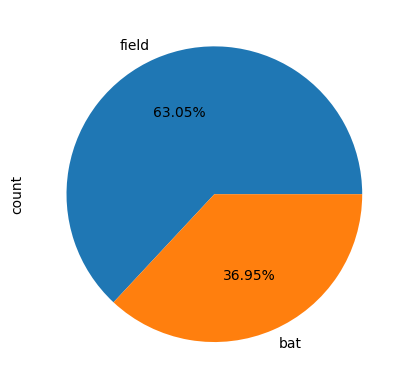

In [33]:
# Create a Pie chart whether a team after winning toss chose bat/bowl

ipl['TossDecision'].value_counts().plot(kind='pie', autopct='%1.2f%%')

In [35]:
# how many matches each team has played

(ipl['Team1'].value_counts() + ipl['Team2'].value_counts()).sort_values(ascending=False)

Mumbai Indians                 231
Royal Challengers Bangalore    226
Kolkata Knight Riders          223
Chennai Super Kings            208
Rajasthan Royals               192
Kings XI Punjab                190
Delhi Daredevils               161
Sunrisers Hyderabad            152
Deccan Chargers                 75
Delhi Capitals                  63
Pune Warriors                   46
Gujarat Lions                   30
Punjab Kings                    28
Gujarat Titans                  16
Rising Pune Supergiant          16
Lucknow Super Giants            15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

In [39]:
# sort_values(series and dataframe) -> ascending -> na_position -> inplace -> multiple cols

movies.sort_values('title_x', ascending=False).head(2)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date,Country,lead_actor
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India),India,Karisma Kapoor
939,Zor Lagaa Ke...Haiya!,tt1479857,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zor_Lagaa_Ke...H...,Zor Lagaa Ke... Haiya!,Zor Lagaa Ke... Haiya!,0,2009,\N,Comedy|Drama|Family,6.4,46,A tree narrates the story of four Mumbai-based...,Children build a tree-house to spy on a beggar...,NaN,Meghan Jadhav|Mithun Chakraborty|Riya Sen|Seem...,NaN,NaN,India,Meghan Jadhav


In [3]:
students = pd.DataFrame(
    {
        'name':['nitish','ankit','rupesh',np.nan,'mrityunjay',np.nan,'rishabh',np.nan,'aditya',np.nan],
        'college':['bit','iit','vit',np.nan,np.nan,'vlsi','ssit',np.nan,np.nan,'git'],
        'branch':['eee','it','cse',np.nan,'me','ce','civ','cse','bio',np.nan],
        'cgpa':[6.66,8.25,6.41,np.nan,5.6,9.0,7.4,10,7.4,np.nan],
        'package':[4,5,6,np.nan,6,7,8,9,np.nan,np.nan]

    }
)

students.sort_values('name')
# by default, NaN values go to last
students.sort_values('name', na_position='first')
# you can also use inplace=True 

,name,college,branch,cgpa,package
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN
8,aditya,NaN,bio,7.40,NaN
1,ankit,iit,it,8.25,5.0
4,mrityunjay,NaN,me,5.60,6.0
0,nitish,bit,eee,6.66,4.0
6,rishabh,ssit,civ,7.40,8.0
2,rupesh,vit,cse,6.41,6.0


In [43]:
movies.sort_values(['year_of_release', 'title_x'], ascending=[True, False])
# order of sorting and order of ascending

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date,Country,lead_actor
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India),India,Karisma Kapoor
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India),India,Ameesha Patel
1622,Yeh Teraa Ghar Yeh Meraa Ghar,tt0298606,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Teraa_Ghar_Y...,Yeh Teraa Ghar Yeh Meraa Ghar,Yeh Teraa Ghar Yeh Meraa Ghar,0,2001,175,Comedy|Drama,5.7,704,In debt; Dayashankar Pandey is forced to go to...,In debt; Dayashankar Pandey is forced to go to...,NaN,Sunil Shetty|Mahima Chaudhry|Paresh Rawal|Saur...,1 nomination,12 October 2001 (India),India,Sunil Shetty
1620,Yeh Raaste Hain Pyaar Ke,tt0292740,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Raaste_Hain_...,Yeh Raaste Hain Pyaar Ke,Yeh Raaste Hain Pyaar Ke,0,2001,149,Drama|Romance,4.0,607,Two con artistes and car thieves Vicky (Ajay ...,Two con artistes and car thieves Vicky (Ajay ...,Love is a journey... not a destination,Ajay Devgn|Madhuri Dixit|Preity Zinta|Vikram G...,NaN,10 August 2001 (India),India,Ajay Devgn
1573,Yaadein (2001 film),tt0248617,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yaadein_(2001_film),Yaadein...,Yaadein...,0,2001,171,Drama|Musical|Romance,4.4,3034,Raj Singh Puri is best friends with L.K. Malho...,Raj Singh Puri is best friends with L.K. Malho...,memories to cherish...,Jackie Shroff|Hrithik Roshan|Kareena Kapoor|Am...,1 nomination,27 June 2001 (India),India,Jackie Shroff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,Article 15 (film),tt10324144,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Article_15_(film),Article 15,Article 15,0,2019,130,Crime|Drama,8.3,13417,In the rural heartlands of India an upright p...,In the rural heartlands of India an upright p...,Farq Bahut Kar Liya| Ab Farq Laayenge.,Ayushmann Khurrana|Nassar|Manoj Pahwa|Kumud Mi...,1 win,28 June 2019 (USA),India,Ayushmann Khurrana
46,Arjun Patiala,tt7881524,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Arjun_Patiala,Arjun Patiala,Arjun Patiala,0,2019,107,Action|Comedy,4.1,676,Arjun Patiala(Diljit Dosanjh)has recently been...,This spoof comedy narrates the story of a cop ...,NaN,Diljit Dosanjh|Kriti Sanon|Varun Sharma|Ronit ...,NaN,26 July 2019 (USA),India,Diljit Dosanjh
10,Amavas,tt8396186,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Amavas,Amavas,Amavas,0,2019,134,Horror|Thriller,2.8,235,Far away from the bustle of the city a young ...,The lives of a couple turn into a nightmare a...,NaN,Ali Asgar|Vivan Bhatena|Nargis Fakhri|Sachiin ...,NaN,8 February 2019 (India),India,Ali Asgar
26,Albert Pinto Ko Gussa Kyun Aata Hai?,tt4355838,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Albert_Pinto_Ko_...,Albert Pinto Ko Gussa Kyun Aata Hai?,Albert Pinto Ko Gussa Kyun Aata Hai?,0,2019,100,Drama,4.8,56,Albert leaves his house one morning without te...,Albert Pinto goes missing one day and his girl...,NaN,Manav Kaul|Nandita Das|,NaN,12 April 2019 (India),India,Manav

In [2]:
# rank (series)

batsman = pd.read_csv('data/batsman_runs_ipl.csv')
batsman['batting_rank'] = batsman['batsman_run'].rank(ascending=False).astype('int16')
# assign a rank to each batsman based on its run (default is ascending)
# Equal runs = Equal rank

batsman.sort_values('batting_rank')

,batter,batsman_run,batting_rank
569,V Kohli,6634,1
462,S Dhawan,6244,2
130,DA Warner,5883,3
430,RG Sharma,5881,4
493,SK Raina,5536,5
...,...,...,...
512,SS Cottrell,0,594
466,S Kaushik,0,594
203,IC Pandey,0,594
467,S Ladda,0,594


In [55]:
# sort_index(series and dataframe)

marks = {
    'maths':67,
    'english':57,
    'science':89,
    'hindi':100
}

marks_series = pd.Series(marks)
marks_series.sort_index()

english     57
hindi      100
maths       67
science     89
dtype: int64

In [ ]:
# set_index(dataframe)

batsman.set_index('batter')
# inplace=True can also be used
# existing index will be lost

,batsman_run,batting_rank
batter,,
A Ashish Reddy,280,166
A Badoni,161,226
A Chandila,4,535
A Chopra,53,329
A Choudhary,25,402
...,...,...
Yash Dayal,0,594
Yashpal Singh,47,343
Younis Khan,3,547


In [ ]:
# reset_index (series and dataframe)

# inplace = True can also be used

# series to dataframe using reset_index

type(marks_series.reset_index())

pandas.core.frame.DataFrame

In [62]:
# unique (series)

temp = pd.Series([1,1,2,2,4,4,5,5, np.nan, np.nan,5])
temp.unique()
# nan values are counted once

array([ 1.,  2.,  4.,  5., nan])

In [ ]:
# Number of unique values
# use len() on unique series 

# or 

# use nunique(), however it doesn't count nan values

In [71]:
# isnull (series and dataframe)

# On series returns a boolean series if it is nan or not 
# On DataFrame, it will return a boolean DataFrame

print(students.isnull())

students[students['name'].isnull()]

    name  college  branch   cgpa  package
0  False    False   False  False    False
1  False    False   False  False    False
2  False    False   False  False    False
3   True     True    True   True     True
4  False     True   False  False    False
5   True    False   False  False    False
6  False    False   False  False    False
7   True     True   False  False    False
8  False     True   False  False     True
9   True    False    True   True     True


,name,college,branch,cgpa,package
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.0,7.0
7,NaN,NaN,cse,10.0,9.0
9,NaN,git,NaN,NaN,NaN


In [72]:
# notnull (series and dataframe)
# complementary to isnull

print(students.notnull())
students[students['name'].notnull()]

    name  college  branch   cgpa  package
0   True     True    True   True     True
1   True     True    True   True     True
2   True     True    True   True     True
3  False    False   False  False    False
4   True    False    True   True     True
5  False     True    True   True     True
6   True     True    True   True     True
7  False    False    True   True     True
8   True    False    True   True    False
9  False     True   False  False    False


,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
4,mrityunjay,NaN,me,5.60,6.0
6,rishabh,ssit,civ,7.40,8.0
8,aditya,NaN,bio,7.40,NaN


In [73]:
# hasnans (series) (Attribute)

# returns True if there exists atleast one nan value in a series
students['name'].hasnans

True

In [74]:
# dropna (series and dataframe)

students

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,mrityunjay,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,aditya,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
students.dropna()
# will drop the entire row if there is even one NaN (due to how='any' parameter)

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0


In [ ]:
students.dropna(how='all')
# will only be removed if all the complete row is NaN
# use subset = [<columns>] to remove NaN values based on that column(s)
# you can also use inplace=True

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
4,mrityunjay,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,aditya,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
# fillna (series and dataframe)

# on a series 
students['name'].fillna('unknown')

0        nitish
1         ankit
2        rupesh
3       unknown
4    mrityunjay
5       unknown
6       rishabh
7       unknown
8        aditya
9       unknown
Name: name, dtype: object

In [81]:
# on a dataframe
students.fillna(0)
# not recommended, handle column wise 
# you can also use method='ffill' to fill in forward direction 
# (will be filled by value preceeding it)
# or method='bfill' (Backward Fill)

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
3,0,0,0,0.00,0.0
4,mrityunjay,0,me,5.60,6.0
5,0,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,0,0,cse,10.00,9.0
8,aditya,0,bio,7.40,0.0
9,0,git,0,0.00,0.0


In [ ]:
# drop_duplicates (series and dataframe)

marks.drop_duplicates()
# use keep='last' to keep the last occurence and drop others
# default is 'first'
# to drop duplicates based on some columns, use subset, the columns are used with & logic
# (should be duplicates in all those columns)

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,70,14


In [93]:
# find the last match played by virat kohli in Delhi

ipl['all players'] = ipl['Team1Players'] + ipl['Team2Players']

kohli_matches = ipl[ipl['all players'].apply(lambda x: 'V Kohli' in x)]
kohli_matches[kohli_matches['City'] == 'Delhi'].drop_duplicates(subset=['City'], keep='first')

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,all players
208,1178421,Delhi,2019-04-28,2019,46,Delhi Capitals,Royal Challengers Bangalore,Arun Jaitley Stadium,Delhi Capitals,bat,...,Delhi Capitals,Runs,16.0,NaN,S Dhawan,"['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...","['PA Patel', 'V Kohli', 'AB de Villiers', 'S D...",BNJ Oxenford,KN Ananthapadmanabhan,"['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ..."


In [6]:
# drop (series and dataframe)

temp = pd.Series([10,2,3,16,45,78,10])
temp.drop(index=[0,6])

1     2
2     3
3    16
4    45
5    78
dtype: int64

In [7]:
students

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,mrityunjay,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,aditya,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [8]:
# to drop columns

students.drop(columns=['branch', 'cgpa'])
# use inplace = True to make it permanent

,name,college,package
0,nitish,bit,4.0
1,ankit,iit,5.0
2,rupesh,vit,6.0
3,NaN,NaN,NaN
4,mrityunjay,NaN,6.0
5,NaN,vlsi,7.0
6,rishabh,ssit,8.0
7,NaN,NaN,9.0
8,aditya,NaN,NaN
9,NaN,git,NaN


In [9]:
# to drop rows

students.drop(index=[0,4])
# inplace will also work in same manner and label indexes can also be used 
# if index is repeating, both will be dropped

,name,college,branch,cgpa,package
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,aditya,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [10]:
# apply (series and dataframe)

points_df = pd.DataFrame(
    {
        '1st point':[(3,4),(-6,5),(0,0),(-10,1),(4,5)],
        '2nd point':[(-3,4),(0,0),(2,2),(10,10),(1,1)]
    }
)

points_df

,1st point,2nd point
0,"(3, 4)","(-3, 4)"
1,"(-6, 5)","(0, 0)"
2,"(0, 0)","(2, 2)"
3,"(-10, 1)","(10, 10)"
4,"(4, 5)","(1, 1)"


In [12]:
# Calculate the Euclidean distance between the two points using apply

def euclidean(row):
    pt_A = row['1st point']
    pt_B = row['2nd point']

    return ((pt_A[0] - pt_B[0])**2 + (pt_A[1] - pt_B[1])**2)**0.5

In [14]:
points_df['Euclidean Distance'] = points_df.apply(euclidean, axis=1)
# axis=1 for sending rows
# axis=0 for sending columns (default)
points_df

,1st point,2nd point,Euclidean Distance
0,"(3, 4)","(-3, 4)",6.000000
1,"(-6, 5)","(0, 0)",7.810250
2,"(0, 0)","(2, 2)",2.828427
3,"(-10, 1)","(10, 10)",21.931712
4,"(4, 5)","(1, 1)",5.000000


In [16]:
# nlargest and nsmallest (series and dataframe)

# returns n largest/smallest rows based on given column
# ascending = True by default for nsmallest
# ascending = False by default for nlargest
# keep={'first', 'last', 'all'} (default 'first')
#     first - keep first occurence in case of duplicates
#     last - keep last occurence in case of duplicates
#     all - keep all the occurences of duplicates

# Equivalent to df.sort_values(columns).head(n)

students.nlargest(3, 'cgpa')    # top 3 cgpa students 

,name,college,branch,cgpa,package
7,NaN,NaN,cse,10.00,9.0
5,NaN,vlsi,ce,9.00,7.0
1,ankit,iit,it,8.25,5.0


In [ ]:
# insert (dataframe)

# used to insert a column in the dataframe at a given index location
# args: loc:position, column:column label, 
#     value:column value (can be scalar, array or series),
#     allow_duplicates=False: to allow a duplicate column or not

students.insert(2, "Program", "B.Tech")

In [19]:
students

,name,college,Program,branch,cgpa,package
0,nitish,bit,B.Tech,eee,6.66,4.0
1,ankit,iit,B.Tech,it,8.25,5.0
2,rupesh,vit,B.Tech,cse,6.41,6.0
3,NaN,NaN,B.Tech,NaN,NaN,NaN
4,mrityunjay,NaN,B.Tech,me,5.60,6.0
5,NaN,vlsi,B.Tech,ce,9.00,7.0
6,rishabh,ssit,B.Tech,civ,7.40,8.0
7,NaN,NaN,B.Tech,cse,10.00,9.0
8,aditya,NaN,B.Tech,bio,7.40,NaN
9,NaN,git,B.Tech,NaN,NaN,NaN


In [22]:
# copy (series and dataframe)

# creates a copy of the series/dataframe
# by default deep=True, so that a deepcopy is created
# changing it won't reflect back in original object
# deep=False creates a shallow copy

newDf = students.head(3).copy()
newDf
# changing newDf won't change students df

,name,college,Program,branch,cgpa,package
0,nitish,bit,B.Tech,eee,6.66,4.0
1,ankit,iit,B.Tech,it,8.25,5.0
2,rupesh,vit,B.Tech,cse,6.41,6.0
